In [32]:
import pandas as pd

In [33]:
listings = pd.read_csv("Listings.csv", encoding="ISO-8859-1")
parse_dates=["host_since"]

C:\Users\Amin\AppData\Local\Temp\ipykernel_10128\4165184075.py:1: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("Listings.csv", encoding="ISO-8859-1")


In [34]:
listings["host_since"]=pd.to_datetime(listings["host_since"])
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [35]:
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [36]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [37]:
paris_listings= (listings.query("city == 'Paris' ").loc[:, ["host_since", "neighbourhood", "accommodates", "city", "price"]])
paris_listings.info()

<class 'pandas.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[us]
 1   neighbourhood  64690 non-null  str           
 2   accommodates   64690 non-null  int64         
 3   city           64690 non-null  str           
 4   price          64690 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 3.0 MB


In [38]:
paris_listings.isna().sum()

host_since       33
neighbourhood     0
accommodates      0
city              0
price             0
dtype: int64

In [39]:
paris_listings.query("accommodates == 0")#.count()

,host_since,neighbourhood,accommodates,city,price
98209,2020-07-20,Pantheon,0,Paris,0
203257,2020-02-04,Batignolles-Monceau,0,Paris,0
203258,2016-10-17,Opera,0,Paris,0
203259,2020-04-24,Luxembourg,0,Paris,0
203260,2020-04-24,Vaugirard,0,Paris,0
203261,2020-07-15,Batignolles-Monceau,0,Paris,0
203263,2016-06-07,Palais-Bourbon,0,Paris,0
203264,2020-09-08,Pantheon,0,Paris,0
203265,2020-09-21,Vaugirard,0,Paris,0
203267,2020-10-29,Observatoire,0,Paris,0


In [40]:
paris_listings_neighbourhood= (
    
    paris_listings
    .groupby("neighbourhood")
    .agg({"price" : "mean"})
    .sort_values("price")
)
paris_listings_neighbourhood.head()

,price
neighbourhood,
Menilmontant,74.942257
Buttes-Chaumont,82.690182
Buttes-Montmartre,87.209479
Reuilly,89.058402
Popincourt,90.559459


In [41]:
paris_listings_accommodates= (
       paris_listings
       .query("neighbourhood == 'Elysee'")
       .groupby("accommodates")
       .agg({"price" : "mean"})
       .sort_values("price")
)
paris_listings_accommodates.head()

,price
accommodates,
0,0.000000
1,79.522222
3,152.828767
2,155.103352
4,212.096070


In [44]:
paris_listings_over_times= (
       paris_listings
       .set_index("host_since")
       .resample("YE")
       .agg({
           "neighbourhood" : "count",
           "price" : "mean"
           })
       
)
paris_listings_over_times.head()

,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


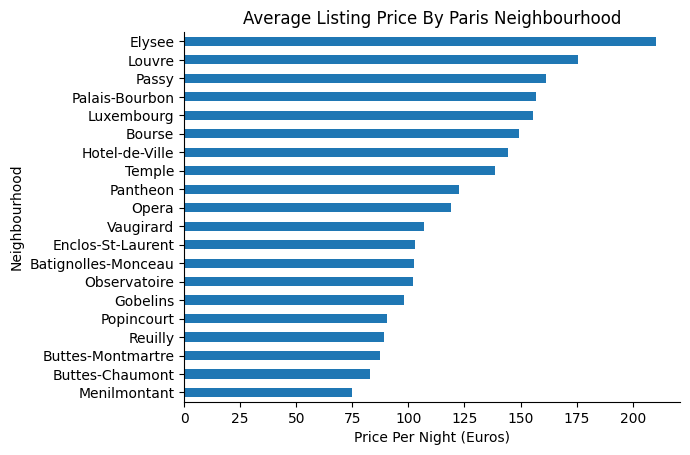

In [47]:
import seaborn as sns


(paris_listings_neighbourhood
 .plot
 .barh(
    title="Average Listing Price By Paris Neighbourhood",
    xlabel="Price Per Night (Euros)",
    ylabel="Neighbourhood",
    legend=None


 )
 )
sns.despine()

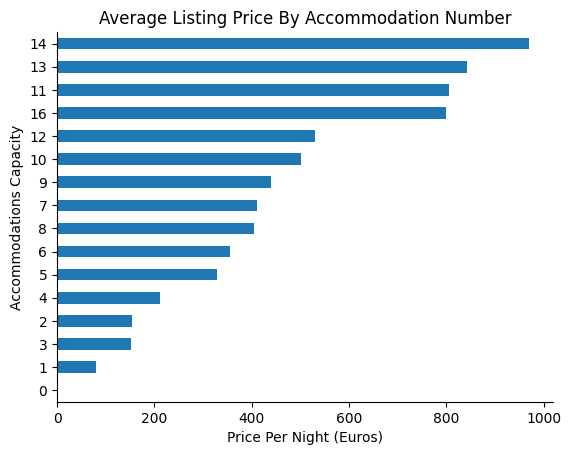

In [49]:
(paris_listings_accommodates
 .plot
 .barh(
    title="Average Listing Price By Accommodation Number",
    xlabel="Price Per Night (Euros)",
    ylabel="Accommodations Capacity",
    legend=None


 )
 )
sns.despine()

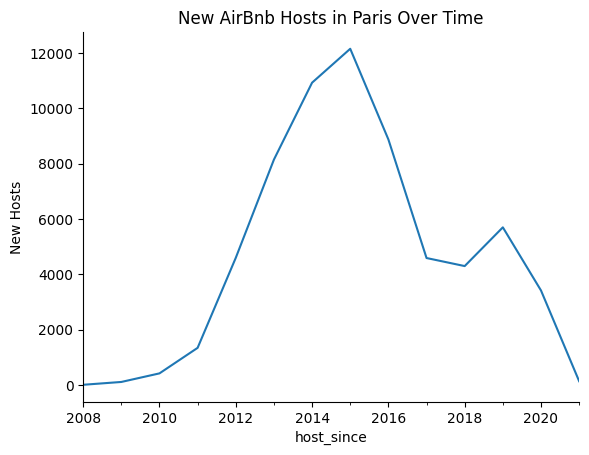

In [51]:
paris_listings_over_times["neighbourhood"].plot(
    ylabel="New Hosts" ,
    title="New AirBnb Hosts in Paris Over Time"

)
sns.despine()

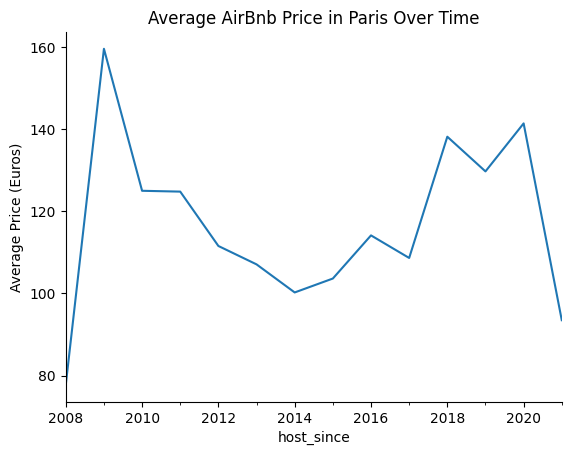

In [ ]:
paris_listings_over_times["price"].plot(
    ylabel="Average Price (Euros)" ,
    title="Average AirBnb Price in Paris Over Time"

)
sns.despine()

Text(0.5, 1.0, '2015 Regulations Lead to Fewer New Hosts, Higher Prices')

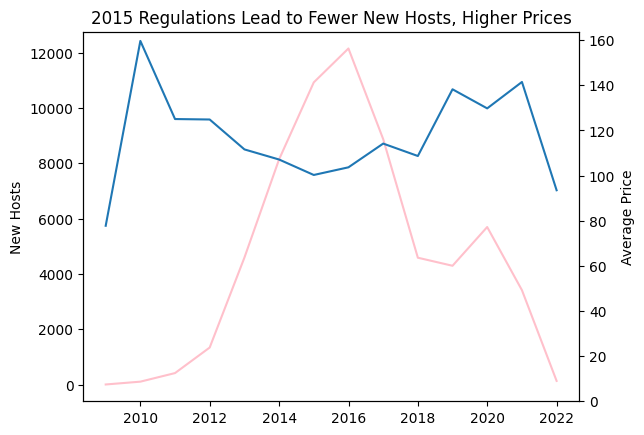

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
   paris_listings_over_times.index,
   paris_listings_over_times["neighbourhood"],
   label="New Hosts",
   c="pink"
)
ax.set_ylabel("New Hosts")

ax2 = ax.twinx()

ax2.plot(
   paris_listings_over_times.index,
   paris_listings_over_times["price"],
   label="Average Price"


)
ax2.set_ylim(0)
ax2.set_ylabel("Average Price")
ax.set_title("2015 Regulations Lead to Fewer New Hosts, Higher Prices")